In [1]:
#Основная программа исследования модели
import loader as ld
import processing as proc
import vizualization as viz
import models as mod
import RandomSearchCV as RSCV
df = ld.load_csv('/content/laptopPrice.csv')

#Data analysis
proc.info(df)

CSV файл /content/laptopPrice.csv загружен.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 823 entries, 0 to 822
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   brand              823 non-null    object
 1   processor_brand    823 non-null    object
 2   processor_name     823 non-null    object
 3   processor_gnrtn    823 non-null    object
 4   ram_gb             823 non-null    object
 5   ram_type           823 non-null    object
 6   ssd                823 non-null    object
 7   hdd                823 non-null    object
 8   os                 823 non-null    object
 9   os_bit             823 non-null    object
 10  graphic_card_gb    823 non-null    object
 11  weight             823 non-null    object
 12  warranty           823 non-null    object
 13  Touchscreen        823 non-null    object
 14  msoffice           823 non-null    object
 15  Price              823 non-null    int64 
 16  

In [2]:
#Первые строки набора данных
proc.head(df)


 Первые пять строк набора данных


,brand,processor_brand,processor_name,processor_gnrtn,ram_gb,ram_type,ssd,hdd,os,os_bit,graphic_card_gb,weight,warranty,Touchscreen,msoffice,Price,rating,Number of Ratings,Number of Reviews
0,ASUS,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,34649,2 stars,3,0
1,Lenovo,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,38999,3 stars,65,5
2,Lenovo,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,39999,3 stars,8,1
3,ASUS,Intel,Core i5,10th,8 GB,DDR4,512 GB,0 GB,Windows,32-bit,2 GB,Casual,No warranty,No,No,69990,3 stars,0,0
4,ASUS,Intel,Celeron Dual,Not Available,4 GB,DDR4,0 GB,512 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,26990,3 stars,0,0


In [3]:
#Типы данных и пропущенные значения
proc.date_type(df)



 Типы данных и пропущенные значения:


,Data Type,Missing values,Missing %,Unique Values
brand,object,0,0.0,8
processor_brand,object,0,0.0,3
processor_name,object,0,0.0,11
processor_gnrtn,object,0,0.0,8
ram_gb,object,0,0.0,4
ram_type,object,0,0.0,6
ssd,object,0,0.0,7
hdd,object,0,0.0,4
os,object,0,0.0,3
os_bit,object,0,0.0,2


In [4]:
df.duplicated().sum()

np.int64(21)

In [5]:
cat_vars, num_vars = proc.classify_variables(df)
print("Классификация данных:")
print('='*40)
print(f"Категориальные данные ({len(cat_vars)}:",cat_vars)
print(f"\nЧисловые данные ({len(num_vars)}:",num_vars)

Классификация данных:
Категориальные данные (16: ['brand', 'processor_brand', 'processor_name', 'processor_gnrtn', 'ram_gb', 'ram_type', 'ssd', 'hdd', 'os', 'os_bit', 'graphic_card_gb', 'weight', 'warranty', 'Touchscreen', 'msoffice', 'rating']

Числовые данные (3: ['Price', 'Number of Ratings', 'Number of Reviews']


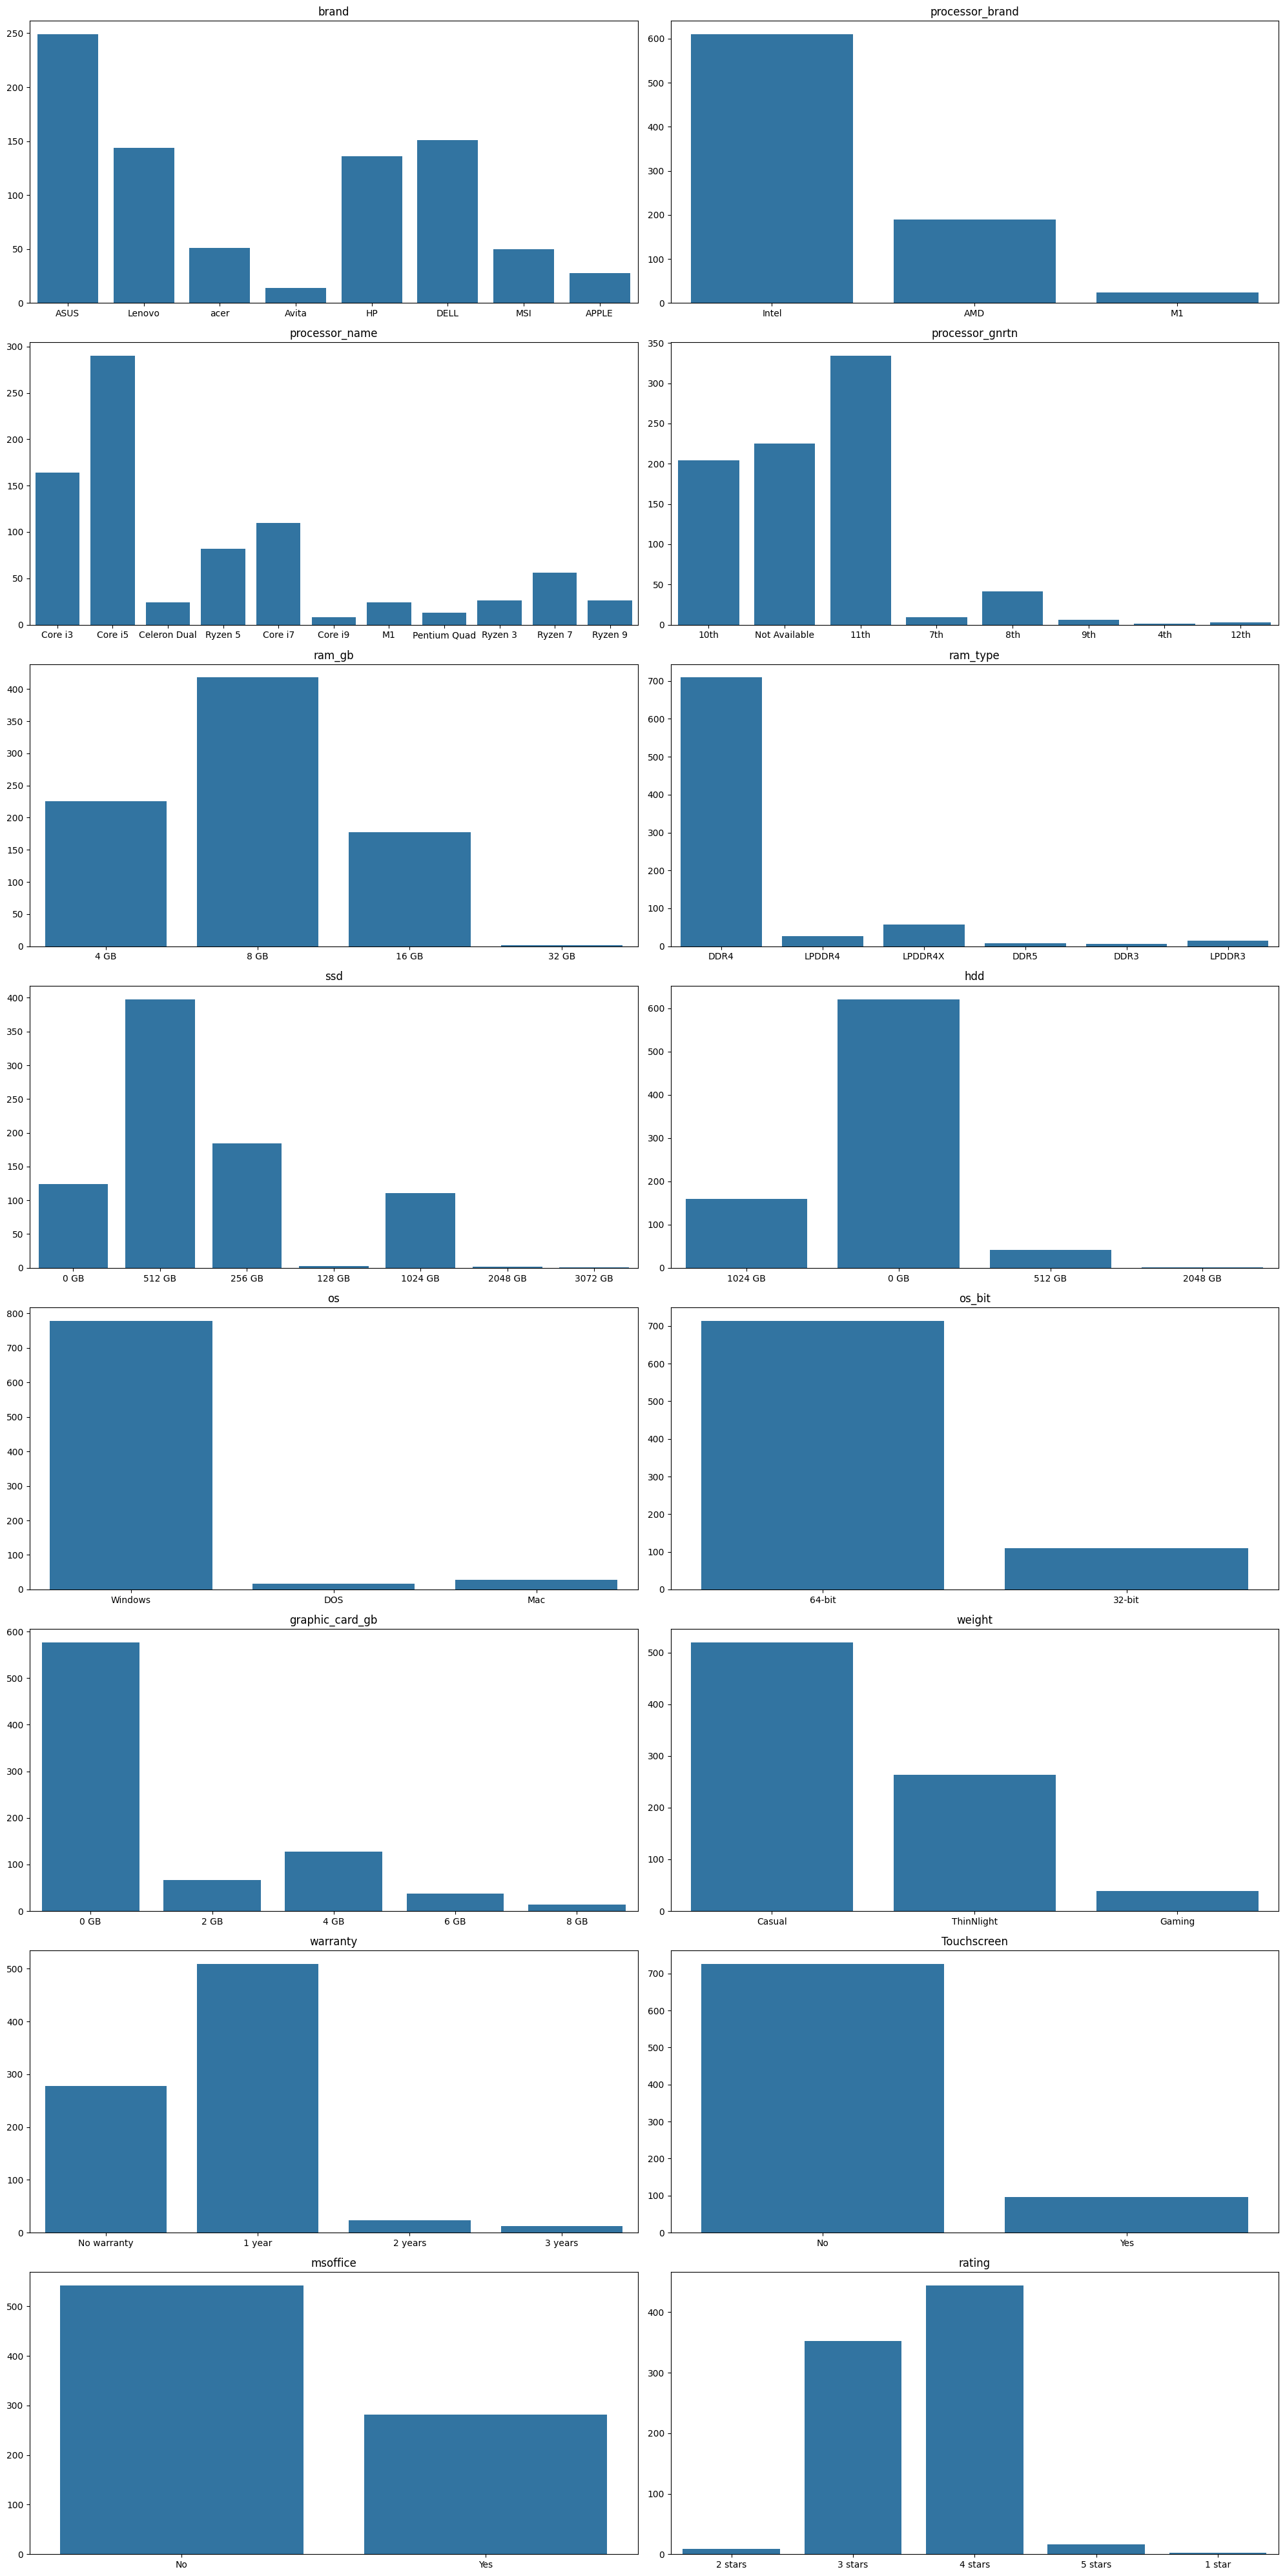

In [6]:
#Графики значений
viz.plot_all_countplot(df)


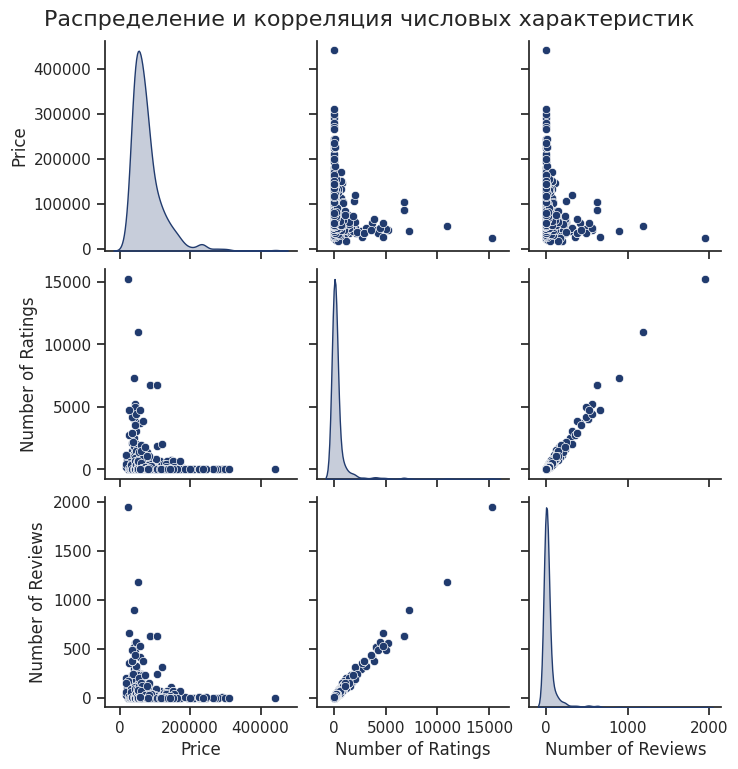

In [7]:
#Распределения и корреляция по всем числовым столбцам.
viz.core(df, num_vars)


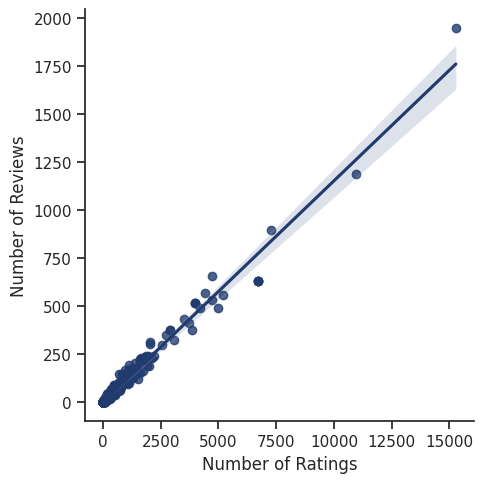

In [8]:
# Линия регрессии для коррелированных столбцов
viz.reg_line_coll(df, 'Number of Ratings', 'Number of Reviews')


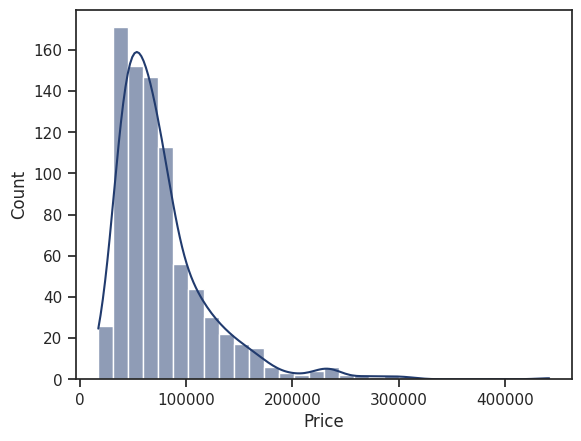

In [9]:
#Распределение цен
viz.Hist(df)


Наблюдается сильная положительная корреляция между количеством оценок и количеством отзывов.
И есть некоторая слабая отрицательная корреляция между ценой и количеством оценок и отзывов, где мы видим, что дорогие ноутбуки, как правило, получают очень мало или совсем не получают отзывов (и оценок).


/content/vizualization.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/content/vizualization.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/content/vizualization.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/content/vizualization.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/content/vizualization.py:51: FutureWarning: 

Passing `palette` without assigning `hue`

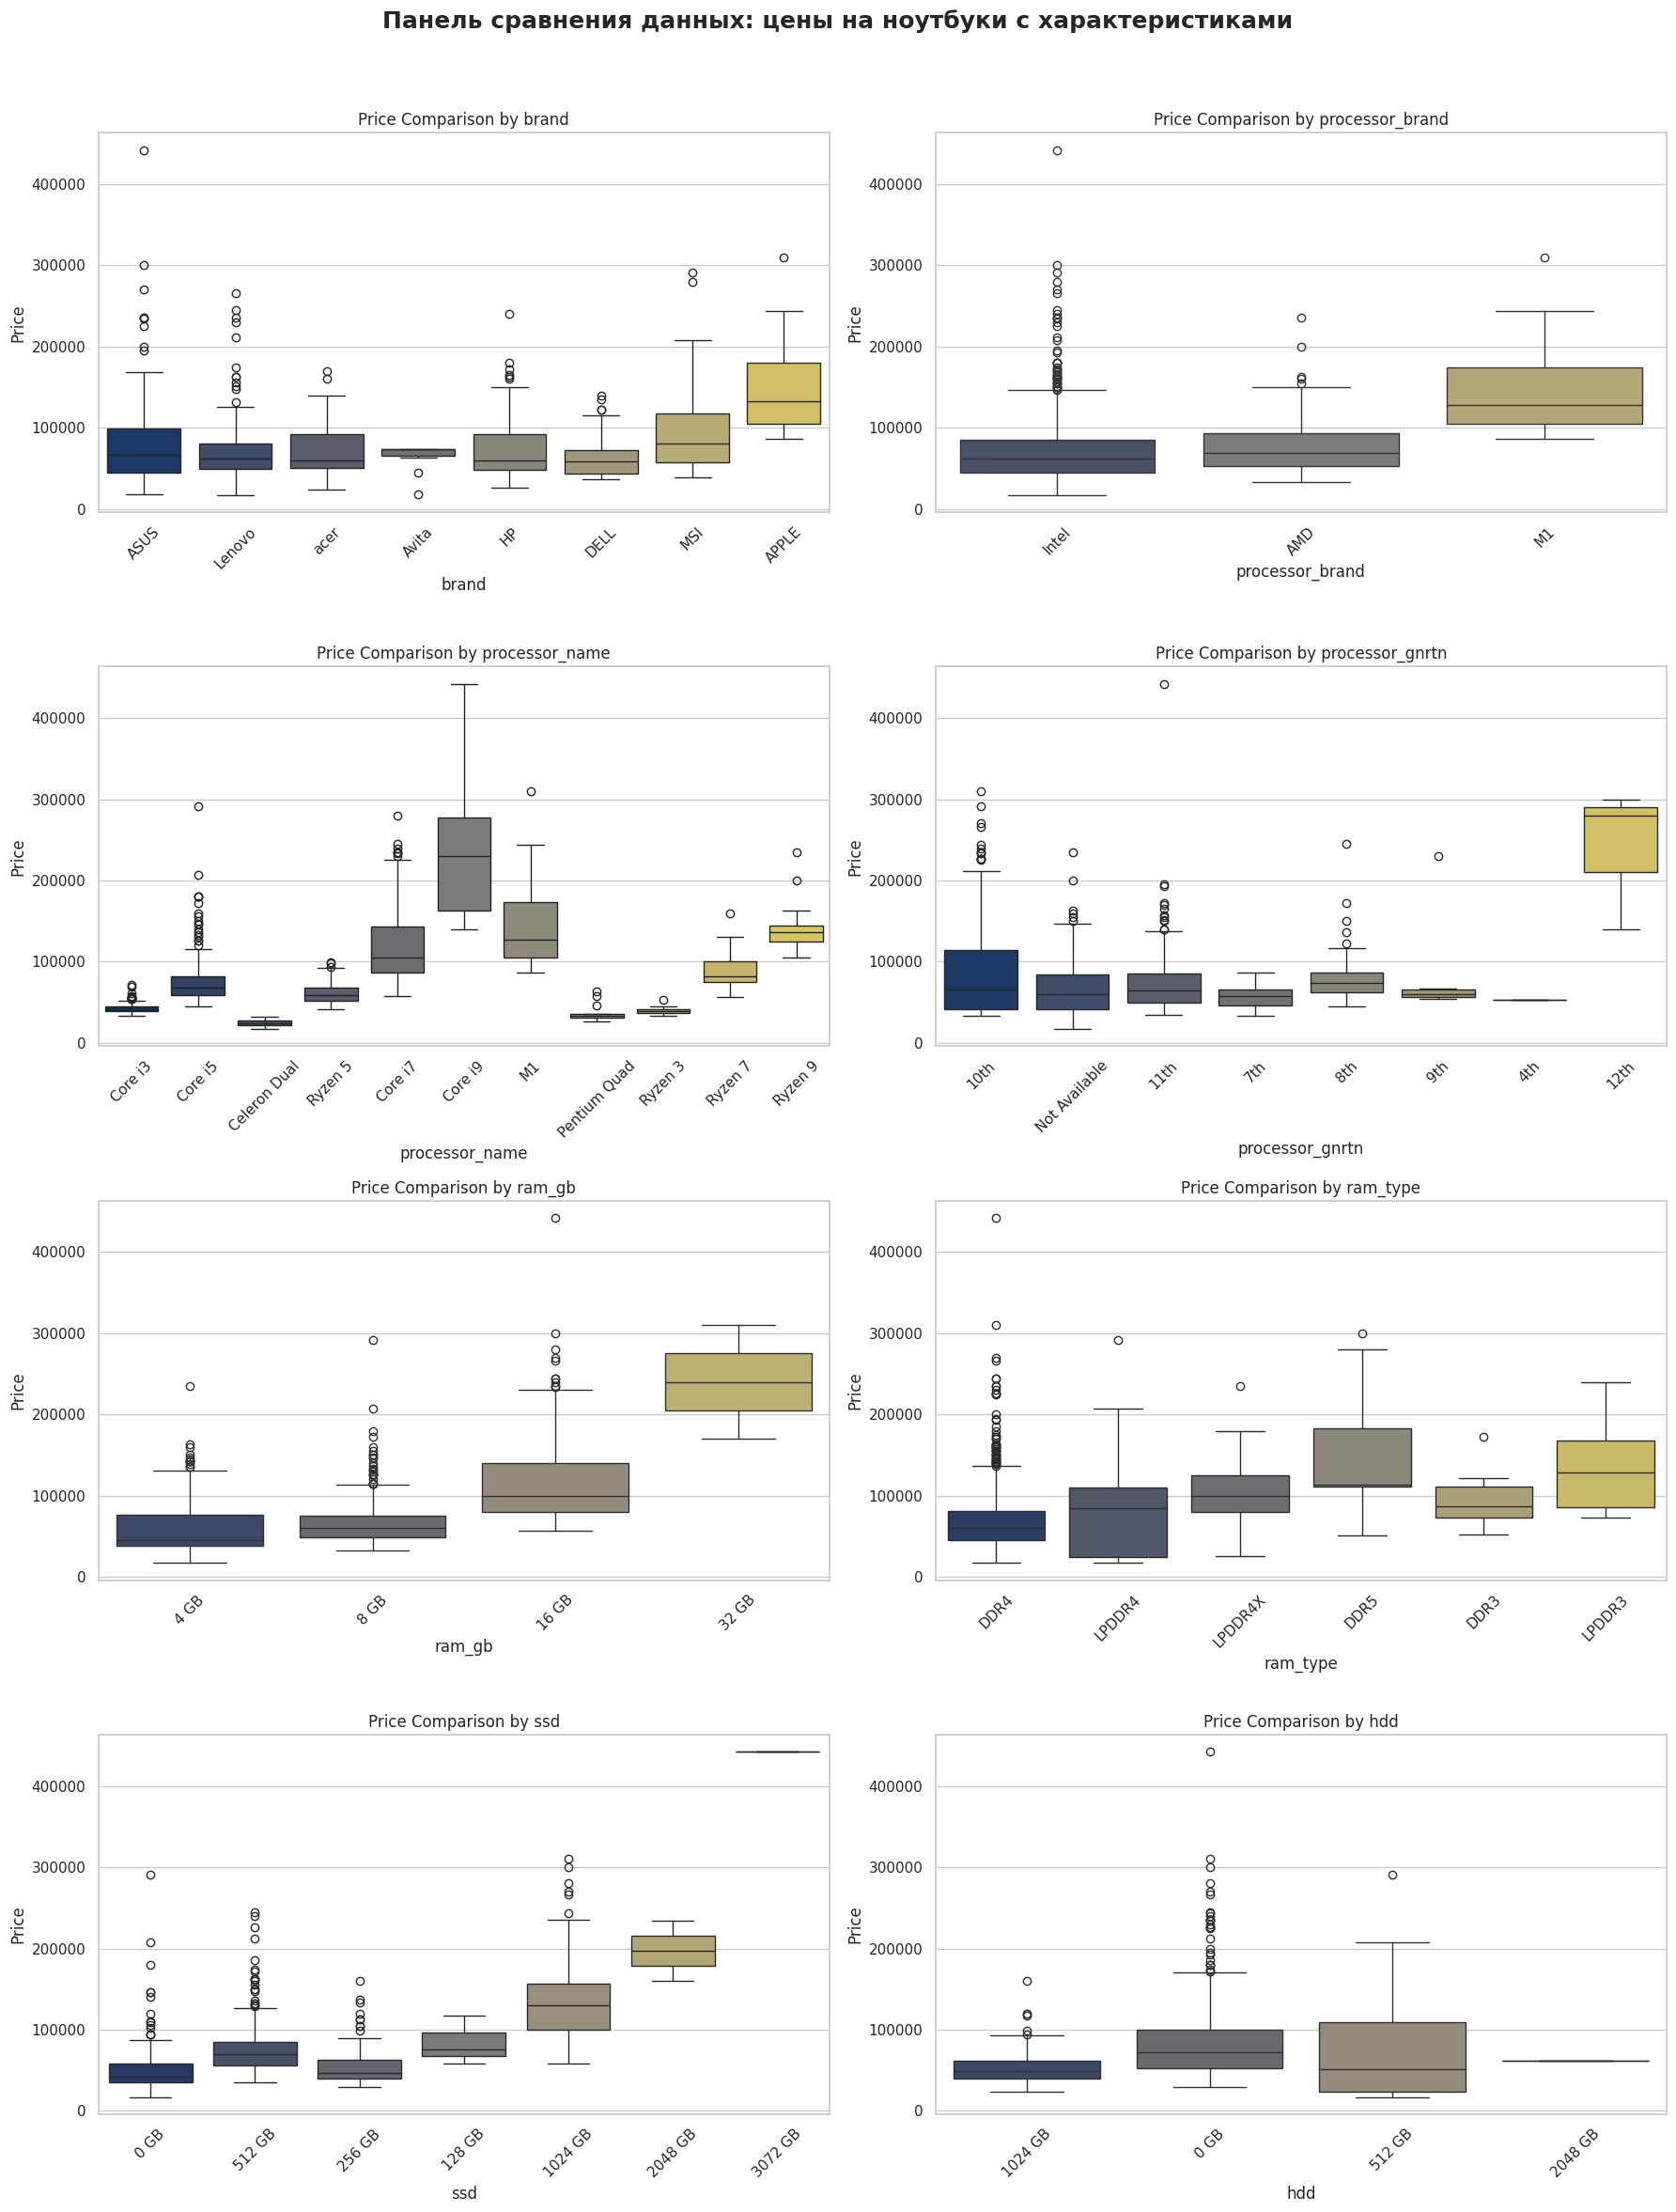

In [10]:
#Сравнение цены c характеристиками ноутбуков
viz.data_comparation(df, cat_vars)


Наблюдения по графикам:

Ноутбуки ASUS встречаются в наборе данных чаще всего, в то время как ноутбуки APPLE в среднем самые дорогие.

В наборе данных преобладают процессоры Intel; однако ноутбуки Apple M1 в среднем самые дорогие.

Core i5 и Core i3 — наиболее распространенные процессоры Intel, а Core i9 — самый дорогой.

В поле «Поколение процессора» много пропущенных значений; среди доступных данных наиболее распространены 10-е и 11-е поколения, и они показывают слабую корреляцию с ценой.

8 ГБ оперативной памяти — наиболее распространенная конфигурация, и больший объем оперативной памяти, как правило, соответствует более высокой цене.

512 ГБ SSD — наиболее популярный вариант хранения данных; размер SSD в основном коррелирует с ценой, с незначительными аномалиями из-за редких конфигураций.
Windows — наиболее распространенная и, как правило, самая доступная операционная система.

Большинство ноутбуков в наборе данных не имеют сенсорного экрана.


In [11]:
df['processor_gnrtn'].value_counts(normalize=True)

,proportion
processor_gnrtn,
11th,0.405832
Not Available,0.273390
10th,0.247874
8th,0.049818
7th,0.010936
9th,0.007290
12th,0.003645
4th,0.001215


Более 27% поколений процессоров в статусе "недоступен".

In [12]:
df[df['processor_gnrtn'] == "Not Available"]['processor_brand'].value_counts()

,count
processor_brand,
AMD,185
Intel,40


In [13]:
df['processor_brand'].value_counts()

,count
processor_brand,
Intel,610
AMD,189
M1,24


Почти у всех ноутбуков AMD отсутствует информация о поколении.

In [14]:
#Можно убрать выбросы
df = proc.remove_outliers(df, 'Price')
df = proc.remove_outliers(df, 'Number of Ratings')
df = proc.remove_outliers(df, 'Number of Reviews')

In [15]:
#Преобразование категориальных данных
df = proc.Encoding(df)
proc.head(df)



 Первые пять строк набора данных


,Price,Number of Ratings,Number of Reviews,brand_ASUS,brand_Avita,brand_DELL,brand_HP,brand_Lenovo,brand_MSI,brand_acer,...,weight_ThinNlight,warranty_2 years,warranty_3 years,warranty_No warranty,Touchscreen_Yes,msoffice_Yes,rating_2 stars,rating_3 stars,rating_4 stars,rating_5 stars
0,34649,3,0,1,0,0,0,0,0,0,...,0,0,0,1,0,0,1,0,0,0
1,38999,65,5,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,1,0,0
2,39999,8,1,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,1,0,0
3,69990,0,0,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0
4,26990,0,0,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0


In [16]:
#Информация о датасете после кодирования объектов
proc.info(df)


<class 'pandas.core.frame.DataFrame'>
Index: 542 entries, 0 to 822
Data columns (total 59 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   Price                          542 non-null    int64
 1   Number of Ratings              542 non-null    int64
 2   Number of Reviews              542 non-null    int64
 3   brand_ASUS                     542 non-null    int64
 4   brand_Avita                    542 non-null    int64
 5   brand_DELL                     542 non-null    int64
 6   brand_HP                       542 non-null    int64
 7   brand_Lenovo                   542 non-null    int64
 8   brand_MSI                      542 non-null    int64
 9   brand_acer                     542 non-null    int64
 10  processor_brand_Intel          542 non-null    int64
 11  processor_brand_M1             542 non-null    int64
 12  processor_name_Core i3         542 non-null    int64
 13  processor_name_Core i5   

In [17]:
# Dependent & independent features
X = df.drop("Price", axis = 1)
y = df["Price"]

# Train - Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [18]:
print("X_train: ",X_train.shape)
print("X_test: ",X_test.shape)
print("y_train: ",y_train.shape)
print("y_test: ",y_test.shape)

X_train:  (433, 58)
X_test:  (109, 58)
y_train:  (433,)
y_test:  (109,)


In [19]:
mod.train_model(X_train, X_test, y_train, y_test)


K Neighbors Regressor 

Model Performance
Mean Absolute Error:  14605.873394495413
Root Mean Squared Error:  18783.76844807308
R2 Score:  0.5978769766816543
-----------------------------------


Decision Tree 

Model Performance
Mean Absolute Error:  10653.48623853211
Root Mean Squared Error:  16834.625649851623
R2 Score:  0.6770015679510928
-----------------------------------


Random Forest Regressor 

Model Performance
Mean Absolute Error:  7876.43987576949
Root Mean Squared Error:  11569.790551898632
R2 Score:  0.8474386647282106
-----------------------------------


Adaboost Regressor 

Model Performance
Mean Absolute Error:  15107.56212466907
Root Mean Squared Error:  17782.98394826084
R2 Score:  0.6395850807597421
-----------------------------------


Gradient Boost Regressor 

Model Performance
Mean Absolute Error:  8200.463833069156
Root Mean Squared Error:  11621.412990962202
R2 Score:  0.8460742220503232
-----------------------------------


LightGBM 

Model Performance
Mean

In [20]:
#Улучшение параметров моделей
best_parametr = RSCV.best_parametr(X_train, y_train)
print(best_parametr) #Улучшенные параметры алгоритмом RandomSearchCV

{'KNN': KNeighborsRegressor(n_neighbors=2), 'Random': RandomForestRegressor(max_depth=15, max_features=7, min_samples_split=12,
                      n_estimators=200), 'Adaboost': AdaBoostRegressor(loss='square', n_estimators=120), 'Gradient': GradientBoostingRegressor(loss='huber', max_depth=4, n_estimators=150), 'Light': LGBMRegressor(colsample_bytree=0.6, learning_rate=0.01, min_child_samples=10,
              n_estimators=300, num_leaves=70, verbosity=-1), 'Tree': DecisionTreeRegressor()}


KNN 

Производительность модели
Mean Absolute Error:  14254.573394495414
Root Mean Squared Error:  19460.943579797335
R2 Score:  0.5683604070390419


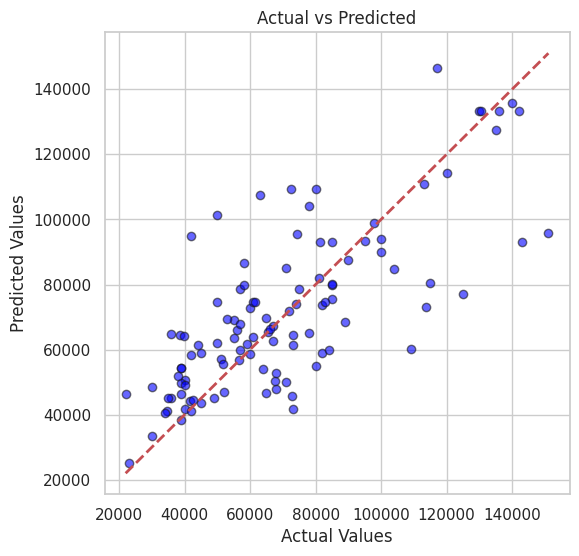



-----------------------------------
Random 

Производительность модели
Mean Absolute Error:  8949.182586320196
Root Mean Squared Error:  11981.700301796585
R2 Score:  0.8363822591089413


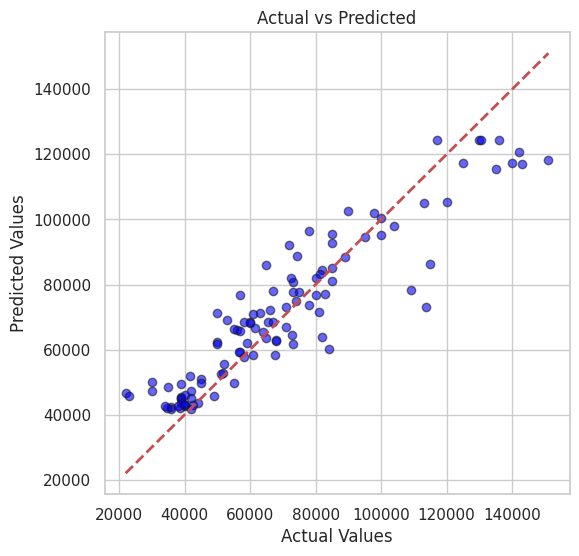



-----------------------------------
Adaboost 

Производительность модели
Mean Absolute Error:  15221.60475388678
Root Mean Squared Error:  17768.44347624507
R2 Score:  0.640174235036805


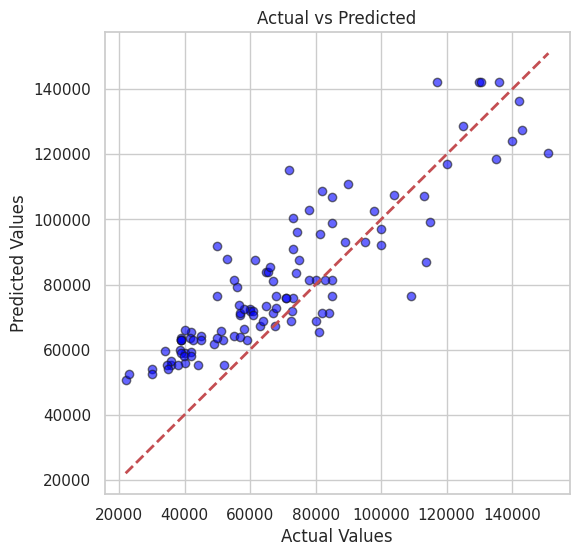



-----------------------------------
Gradient 

Производительность модели
Mean Absolute Error:  8066.238888649278
Root Mean Squared Error:  11837.055825845931
R2 Score:  0.8403088388125578


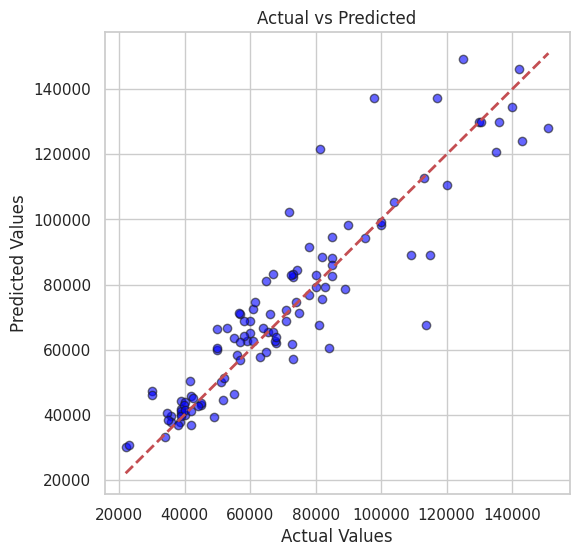



-----------------------------------
Light 

Производительность модели
Mean Absolute Error:  7704.786492691086
Root Mean Squared Error:  10678.096645213667
R2 Score:  0.8700485344527177


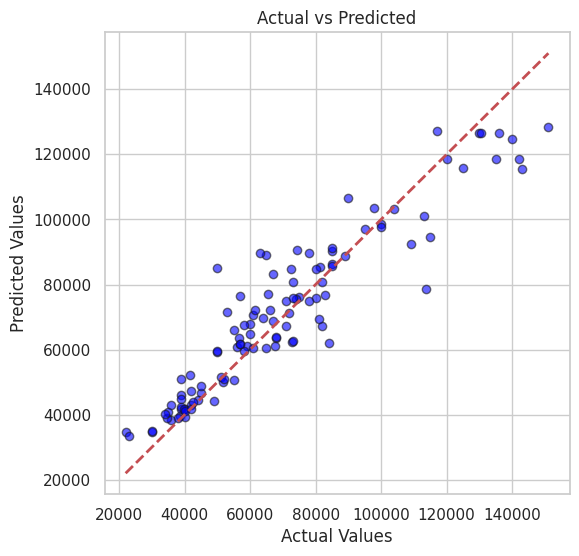



-----------------------------------
Tree 

Производительность модели
Mean Absolute Error:  10467.899082568807
Root Mean Squared Error:  16765.727486083466
R2 Score:  0.6796399943063995


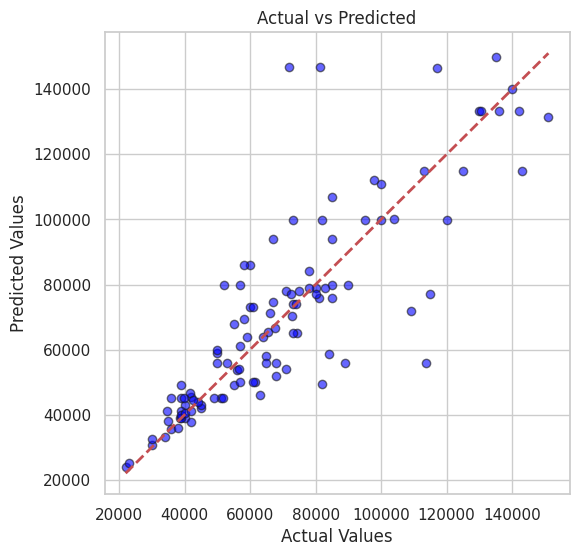



-----------------------------------


In [23]:
#Использование оптимальных гиперпараметров для моделей и изучение результатов
results_rmse, results_r2 = mod.train_best_models(best_parametr, X_train, X_test, y_train, y_test)

In [33]:
import pandas as pd
results_rmse_df = pd.DataFrame(results_rmse, index=range(0,1)).T.rename(columns={0: 'RMSE'}).sort_values('RMSE', ascending=False)
results_rmse_df.T

,KNN,Adaboost,Tree,Random,Gradient,Light
RMSE,19460.94358,17768.443476,16765.727486,11981.700302,11837.055826,10678.096645


In [30]:
results_r2_df = pd.DataFrame(results_r2, index=range(0,1)).T.rename(columns={0: 'RMSE'}).sort_values('RMSE', ascending=False)
results_r2_df.T

,Light,Gradient,Random,Tree,Adaboost,KNN
RMSE,0.870049,0.840309,0.836382,0.67964,0.640174,0.56836


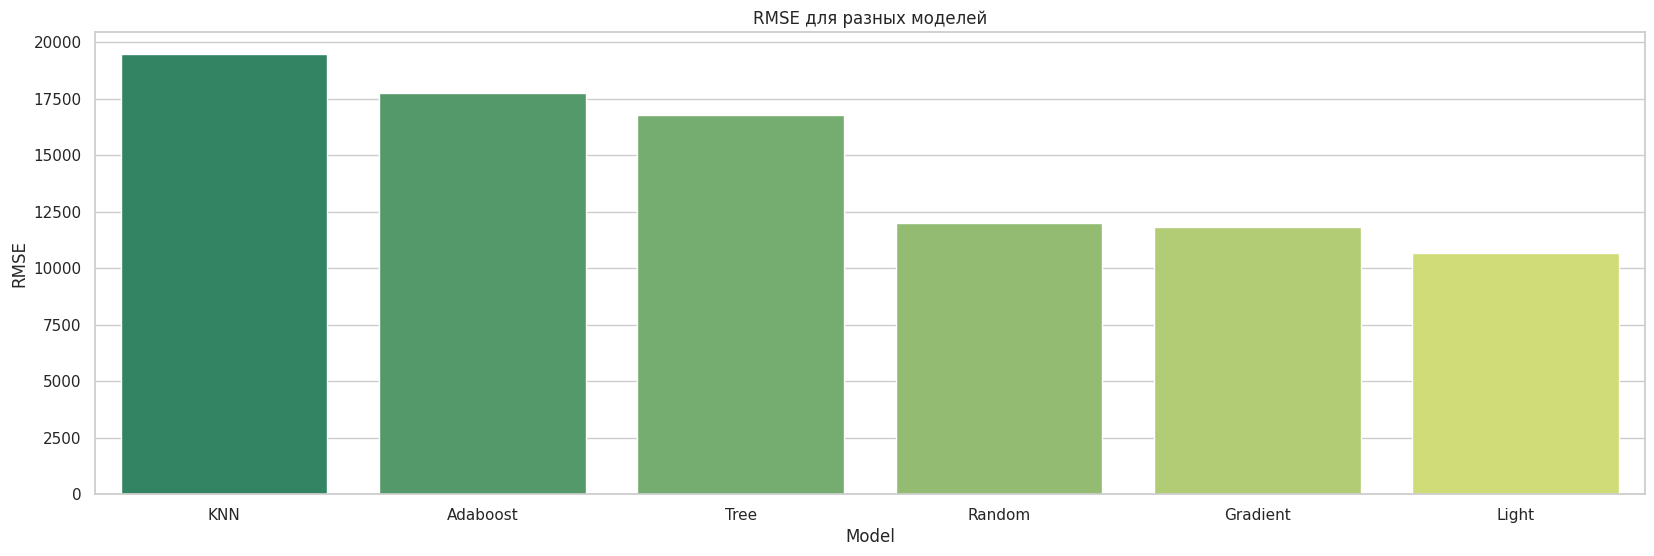

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize = (20, 6))
sns.barplot(x= results_rmse_df.index, y = results_rmse_df['RMSE'], palette = 'summer')
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.title('RMSE для разных моделей');

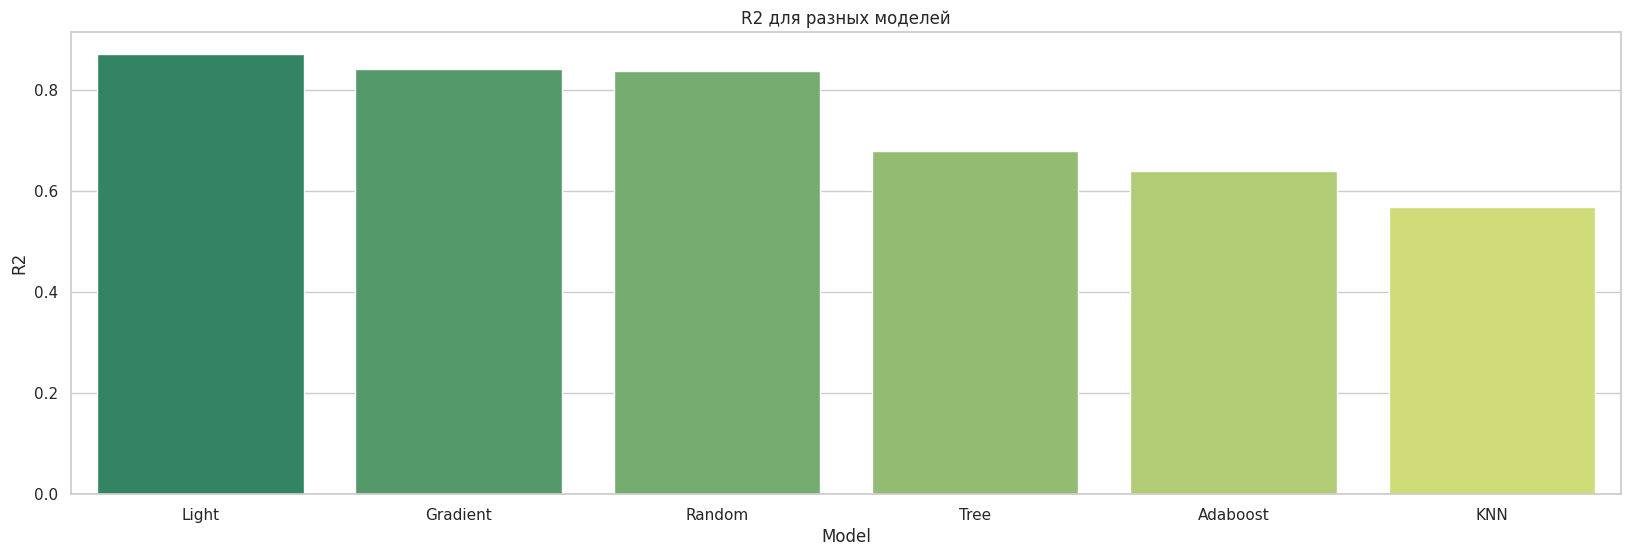

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize = (20, 6))
sns.barplot(x= results_r2_df.index, y = results_r2_df['RMSE'], palette = 'summer')
plt.xlabel('Model')
plt.ylabel('R2')
plt.title('R2 для разных моделей');

Предсказание цен на ноутбуки возможно осуществлять с помощью моделей регрессии.

Оптимальныями из них будут GradientBoostingRegressor и LGBMRegressor.

Марка, тип процессора, оперативная память, объем хранилища и операционная система — все это влияет на ценообразование.

Больший объем оперативной памяти и SSD-накопителя, как правило, приводит к более высоким ценам.

Ноутбуки Apple и высокопроизводительные процессоры являются самыми дорогими, в то время как распространенные конфигурации, такие как 8 ГБ оперативной памяти и 512 ГБ SSD, более доступны по цене.
